<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/Gaussian%20Mixture%20Model%20-%20Riya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Libraries and Dataset

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

# Load data
gp = pd.read_csv("/content/GP_PCA_Dataset.csv")

ANALYSIS 1: ALL FEATURES (Initial Exploration)

Analyzing 22 features
Complete cases: 13065

--------------------------------------------------------------------------------
VIF RESULTS (sorted by VIF):
--------------------------------------------------------------------------------
              Feature        VIF    Status Category
avg_rank_score_scaled 272.531280    SEVERE   Severe
max_rank_score_scaled 261.458397    SEVERE   Severe
        whyplay_novel  86.032796    SEVERE   Severe
    whyplay_improving  76.740796    SEVERE   Severe
                  Age  61.918680    SEVERE   Severe
       Gender_encoded  59.834639    SEVERE   Severe
     Platform_encoded  48.159376      HIGH     High
      whyplay_winning  34.298582      HIGH     High
       rank_group_num  16.148127      HIGH     High
       Playstyle_enum  12.668995      HIGH     High
     whyplay_relaxing  11.412816      HIGH     High
         Game_encoded   7.910071  MODERATE Moderate
         Work_encoded   5.680585  MODERA

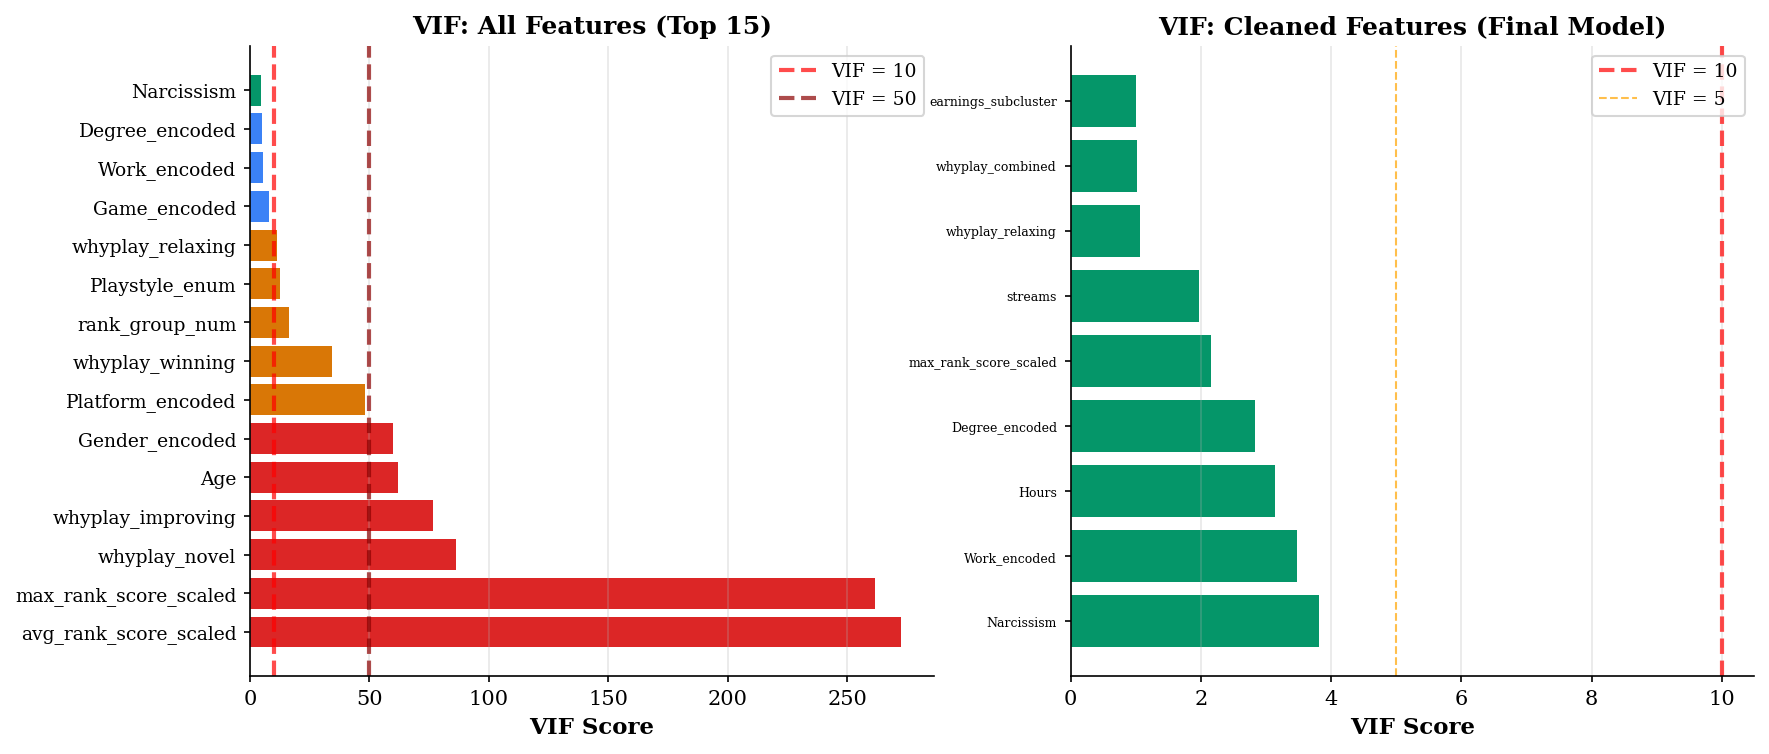

In [ ]:
# DEFINE FEATURES

# Option 1: All potential features
all_features = [
    # Rank/Skill
    'avg_rank_score_scaled', 'max_rank_score_scaled', 'rank_group_num',

    # Gaming Behavior
    'Hours', 'streams',

    # Motivations
    'whyplay_winning', 'whyplay_improving', 'whyplay_relaxing',
    'whyplay_having_fun', 'whyplay_combined', 'whyplay_novel',
    'whyplay_novel_cluster',

    # Demographics
    'Age', 'Gender_encoded', 'Work_encoded', 'Degree_encoded',

    # Psychological
    'Narcissism',

    # Context
    'Game_encoded', 'Platform_encoded', 'Playstyle_enum',

    # Economics
    'earnings_cluster', 'earnings_subcluster',
]

# Option 2: Cleaned features
cleaned_features = [
    "max_rank_score_scaled", "Hours", "streams", "Narcissism",
    "Work_encoded", "Degree_encoded", "whyplay_relaxing",
    "whyplay_combined", "earnings_subcluster"
]


# FUNCTION: CALCULATE VIF

def calculate_vif(df, features):
    """Calculate VIF for given features"""
    # Get clean data
    clean_data = df[features].dropna()

    vif_data = []
    for i, col in enumerate(features):
        try:
            vif = variance_inflation_factor(clean_data.values, i)

            # Categorize
            if vif < 5:
                status = " GOOD"
                category = "Good"
            elif vif < 10:
                status = " MODERATE"
                category = "Moderate"
            elif vif < 50:
                status = " HIGH"
                category = "High"
            else:
                status = " SEVERE"
                category = "Severe"

            vif_data.append({
                'Feature': col,
                'VIF': vif,
                'Status': status,
                'Category': category
            })
        except Exception as e:
            vif_data.append({
                'Feature': col,
                'VIF': np.nan,
                'Status': 'Error',
                'Category': 'Error'
            })

    return pd.DataFrame(vif_data), clean_data

# FUNCTION: CORRELATION ANALYSIS

def find_high_correlations(df, features, threshold=0.7):
    """Find pairs of features with high correlation"""
    clean_data = df[features].dropna()
    corr_matrix = clean_data.corr()

    high_corr_pairs = []
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > threshold:
                high_corr_pairs.append({
                    'Feature_1': features[i],
                    'Feature_2': features[j],
                    'Correlation': corr_val
                })

    return pd.DataFrame(high_corr_pairs), corr_matrix

# ANALYSIS 1: ALL FEATURES

print("="*80)
print("ANALYSIS 1: ALL FEATURES (Initial Exploration)")
print("="*80)

# Filter to available features
available_all = [f for f in all_features if f in gp.columns]
print(f"\nAnalyzing {len(available_all)} features")

# Calculate VIF
vif_all, data_all = calculate_vif(gp, available_all)
print(f"Complete cases: {len(data_all)}")

# Display VIF results
print("\n" + "-"*80)
print("VIF RESULTS (sorted by VIF):")
print("-"*80)
vif_all_sorted = vif_all.sort_values('VIF', ascending=False)
print(vif_all_sorted.to_string(index=False))

# Find high correlations
print("\n" + "-"*80)
print("HIGH CORRELATIONS (|r| > 0.7):")
print("-"*80)
high_corr_all, corr_matrix_all = find_high_correlations(gp, available_all, threshold=0.7)
if len(high_corr_all) > 0:
    print(high_corr_all.sort_values('Correlation', key=abs, ascending=False).to_string(index=False))
else:
    print("None found")


# ANALYSIS 2: CLEANED FEATURES

print("\n\n" + "="*80)
print("ANALYSIS 2: CLEANED FEATURES (Your Final Model)")
print("="*80)

# Filter to available features
available_cleaned = [f for f in cleaned_features if f in gp.columns]
print(f"\nAnalyzing {len(available_cleaned)} features")

# Calculate VIF
vif_cleaned, data_cleaned = calculate_vif(gp, available_cleaned)
print(f"Complete cases: {len(data_cleaned)}")

# Display VIF results
print("\n" + "-"*80)
print("VIF RESULTS (sorted by VIF):")
print("-"*80)
vif_cleaned_sorted = vif_cleaned.sort_values('VIF', ascending=False)
print(vif_cleaned_sorted.to_string(index=False))

# COMPARISON

print("\n\n" + "="*80)
print("COMPARISON: ALL vs CLEANED FEATURES")
print("="*80)

comparison_data = []
for feature in available_cleaned:
    vif_before = vif_all[vif_all['Feature'] == feature]['VIF'].values
    vif_after = vif_cleaned[vif_cleaned['Feature'] == feature]['VIF'].values

    if len(vif_before) > 0 and len(vif_after) > 0:
        reduction = vif_before[0] - vif_after[0]
        pct_reduction = (reduction / vif_before[0]) * 100 if vif_before[0] > 0 else 0

        comparison_data.append({
            'Feature': feature,
            'VIF_Before': vif_before[0],
            'VIF_After': vif_after[0],
            'Reduction': reduction,
            'Pct_Reduction': pct_reduction
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Reduction', ascending=False)

print("\nVIF Changes After Removing Correlated Features:")
print("-"*80)
print(comparison_df.to_string(index=False))

# VISUALIZATIONS

print("\n\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 12))

# 1. VIF Comparison - All Features
ax1 = plt.subplot(2, 3, 1)
vif_all_plot = vif_all_sorted[~vif_all_sorted['VIF'].isna()].head(15)
colors = ['#dc2626' if v > 50 else '#d97706' if v > 10 else '#3b82f6' if v > 5 else '#059669'
          for v in vif_all_plot['VIF']]
ax1.barh(range(len(vif_all_plot)), vif_all_plot['VIF'], color=colors)
ax1.set_yticks(range(len(vif_all_plot)))
ax1.set_yticklabels(vif_all_plot['Feature'], fontsize=9)
ax1.set_xlabel('VIF Score', fontsize=11, fontweight='bold')
ax1.set_title('VIF: All Features (Top 15)', fontsize=12, fontweight='bold')
ax1.axvline(10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='VIF = 10')
ax1.axvline(50, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label='VIF = 50')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# 2. VIF - Cleaned Features
ax2 = plt.subplot(2, 3, 2)
colors_clean = ['#d97706' if v > 5 else '#059669' for v in vif_cleaned_sorted['VIF']]
ax2.barh(range(len(vif_cleaned_sorted)), vif_cleaned_sorted['VIF'], color=colors_clean)
ax2.set_yticks(range(len(vif_cleaned_sorted)))
ax2.set_yticklabels(vif_cleaned_sorted['Feature'], fontsize=6)
ax2.set_xlabel('VIF Score', fontsize=11, fontweight='bold')
ax2.set_title('VIF: Cleaned Features (Final Model)', fontsize=12, fontweight='bold')
ax2.axvline(10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='VIF = 10')
ax2.axvline(5, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='VIF = 5')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)




### Mixed Model

In [ ]:
print("="*80)
print("MIXED MODEL")
print("="*80)


gp = gp.reset_index(drop=True)

outcomes = ['GAD_T', 'SPIN_T_imputed', 'SWL_T']

# Cleaned features after multicollinearity diagnostics
cleaned_features = [
    "max_rank_score_scaled", "Hours", "streams", "Narcissism",
    "Work_encoded", "Degree_encoded", "whyplay_relaxing",
    "whyplay_combined", "earnings_subcluster"
]

print(f"\nFeatures included ({len(cleaned_features)}): {cleaned_features}")

results_summary = []

for outcome in outcomes:
    print(f"\n{'='*80}\nANALYZING: {outcome}\n{'='*80}")

    model_data = gp[[outcome] + cleaned_features + ['Game_encoded']].dropna()
    print(f"Complete cases: {len(model_data)}, Games: {model_data['Game_encoded'].nunique()}")

    formula = f"{outcome} ~ " + " + ".join(cleaned_features)

    try:
        model = smf.mixedlm(formula, model_data, groups=model_data['Game_encoded'])
        fit = model.fit(method='powell', maxiter=2000, reml=True)

        print("✓ Model converged successfully!")
        print(fit.summary().as_text())

        # ICC calculation
        var_game = fit.cov_re.iloc[0,0]
        var_residual = fit.scale
        icc = var_game / (var_game + var_residual)

        # Significant predictors
        sig = [(p, fit.params[p], fit.conf_int().loc[p], fit.pvalues[p])
               for p in fit.params.index if p != 'Intercept' and fit.pvalues[p]<0.05]

        if sig:
            sig_df = pd.DataFrame([
                {'Predictor': p, 'β': f"{coef:.4f}",
                 '95% CI': f"[{ci[0]:.4f}, {ci[1]:.4f}]",
                 'p': f"{pval:.4f}",
                 'Effect': "↑" if coef>0 else "↓"}
                for p, coef, ci, pval in sig
            ])
            print("\nSignificant predictors (p < 0.05):")
            print(sig_df.to_string(index=False))
        else:
            print("\nNo significant predictors at p < 0.05")

        # Key effects
        for key in ['max_rank_score_scaled','Hours']:
            if key in fit.params.index:
                coef = fit.params[key]
                pval = fit.pvalues[key]
                if pval < 0.05:
                    print(f"✓ {key} → {'HIGHER' if coef>0 else 'LOWER'} {outcome} (β={coef:.4f}, p={pval:.4f})")

        print(f"\nICC: {icc:.4f} ({icc*100:.1f}% variance between games)")

        results_summary.append({'Outcome': outcome, 'Status': 'Success', 'N': len(model_data),
                                'ICC': f"{icc:.4f}", 'N_sig': len(sig)})

    except Exception as e:
        print(f"✗ Model failed: {e}")
        results_summary.append({'Outcome': outcome, 'Status': f'Failed: {str(e)[:30]}', 'N': len(model_data)})

# Summary
print(f"\n{'='*80}\nSUMMARY\n{'='*80}")
print(pd.DataFrame(results_summary).to_string(index=False))
print(f"\n{'='*80}\nANALYSIS COMPLETE!\n{'='*80}")


MIXED MODEL

Features included (9): ['max_rank_score_scaled', 'Hours', 'streams', 'Narcissism', 'Work_encoded', 'Degree_encoded', 'whyplay_relaxing', 'whyplay_combined', 'earnings_subcluster']

ANALYZING: GAD_T
Complete cases: 13065, Games: 11
✓ Model converged successfully!
             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   GAD_T      
No. Observations:    13065     Method:               REML       
No. Groups:          11        Scale:                21.4320    
Min. group size:     18        Log-Likelihood:       -38576.6666
Max. group size:     10989     Converged:            Yes        
Mean group size:     1187.7                                     
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              4.442                                    
max_rank_score_scaled -

### AGE focused Mixed Model

In [ ]:

print("="*80)
print("OPTION 2: AGE-FOCUSED MIXED MODEL")
print("="*80)
print("\nSimplified model with Age (no Education/Work to avoid multicollinearity)")

gp = gp.reset_index(drop=True)

outcomes = ['GAD_T', 'SPIN_T_imputed', 'SWL_T']

# Age-focused features (simplified to avoid multicollinearity)
age_model_features = [
    "Age",                      # ← PRIMARY: Age instead of Education/Work
    "max_rank_score_scaled",    # Skill/rank
    "Hours",                    # Time investment
    "streams",                  # Streaming behavior
    "Narcissism",               # Personality
    # Removed to avoid multicollinearity with Age:
    # - Work_encoded (VIF would be high with Age)
    # - Degree_encoded (VIF would be high with Age)
]

print(f"\nFeatures included: {len(age_model_features)}")
print("  - Age (primary demographic variable)")
print("  - max_rank_score_scaled (skill)")
print("  - Hours (time investment)")
print("  - streams (streaming behavior)")
print("  - Narcissism (personality)")
print("\nNote: Removed Education and Work to avoid multicollinearity with Age")


# RUN AGE-FOCUSED MODELS

results_summary = []

for outcome in outcomes:
    print(f"\n{'='*80}")
    print(f"ANALYZING: {outcome}")
    print(f"{'='*80}")

    # Prepare data
    all_vars = [outcome] + age_model_features + ['Game_encoded']
    model_data = gp[all_vars].dropna()

    print(f"\nComplete cases: {len(model_data)}")
    print(f"Games: {model_data['Game_encoded'].nunique()}")
    print(f"Age range: {model_data['Age'].min():.0f} - {model_data['Age'].max():.0f} years")
    print(f"Age mean: {model_data['Age'].mean():.1f} (SD: {model_data['Age'].std():.1f})")

    # Create formula
    formula = f"{outcome} ~ " + " + ".join(age_model_features)

    print(f"\n{'-'*80}")
    print("FITTING MIXED MODEL WITH AGE")
    print(f"{'-'*80}")

    try:
        # Fit the model
        model = smf.mixedlm(formula, model_data,
                           groups=model_data['Game_encoded'])
        fit = model.fit(method='powell', maxiter=2000, reml=True)

        print("✓ Model converged successfully!")
        print("\n" + fit.summary().as_text())

        # Extract diagnostics
        var_game = fit.cov_re.iloc[0,0]
        var_residual = fit.scale
        icc = var_game / (var_game + var_residual)

        print(f"\n{'='*80}")
        print("MODEL DIAGNOSTICS")
        print(f"{'='*80}")
        print(f"AIC: {fit.aic:.2f}")
        print(f"BIC: {fit.bic:.2f}")
        print(f"Log-Likelihood: {fit.llf:.2f}")
        print(f"\nVariance Components:")
        print(f"  Between-game variance: {var_game:.4f}")
        print(f"  Within-game variance: {var_residual:.4f}")
        print(f"  ICC: {icc:.4f} ({icc*100:.2f}% of variance is between games)")

        # Significant predictors
        print(f"\n{'='*80}")
        print("SIGNIFICANT PREDICTORS (p < 0.05)")
        print(f"{'='*80}")

        sig_results = []
        for param in fit.params.index:
            if param == 'Intercept':
                continue
            coef = fit.params[param]
            pval = fit.pvalues[param]
            ci_lower, ci_upper = fit.conf_int().loc[param]

            if pval < 0.05:
                direction = "↑" if coef > 0 else "↓"
                sig_level = "***" if pval < 0.001 else "**" if pval < 0.01 else "*"
                sig_results.append({
                    'Predictor': param,
                    'β': f"{coef:.4f}",
                    '95% CI': f"[{ci_lower:.4f}, {ci_upper:.4f}]",
                    'p': f"{pval:.4f}",
                    'Sig': sig_level,
                    'Effect': direction
                })

        if sig_results:
            sig_df = pd.DataFrame(sig_results)
            print(sig_df.to_string(index=False))
        else:
            print("No significant predictors at p < 0.05")

        # AGE-SPECIFIC INTERPRETATION
        print(f"\n{'='*80}")
        print(f"AGE EFFECTS ON {outcome}")
        print(f"{'='*80}")

        if 'Age' in fit.params.index:
            age_coef = fit.params['Age']
            age_pval = fit.pvalues['Age']
            age_ci = fit.conf_int().loc['Age']

            if age_pval < 0.05:
                direction_word = "HIGHER" if age_coef > 0 else "LOWER"
                years_effect = abs(age_coef * 10)
                print(f"✓ Age is SIGNIFICANT (p = {age_pval:.4f})")
                print(f"  → Each year older: {age_coef:+.4f} change in {outcome}")
                print(f"  → 10 years older: {age_coef*10:+.4f} change in {outcome}")
                print(f"  → Older age → {direction_word} {outcome}")
                print(f"  → 95% CI: [{age_ci[0]:.4f}, {age_ci[1]:.4f}]")

                # Age-based prediction example
                young_age = 20
                old_age = 35
                age_diff = (old_age - young_age) * age_coef
                print(f"\n  Example:")
                print(f"    20-year-old predicted {outcome}: Baseline")
                print(f"    35-year-old predicted {outcome}: Baseline {age_diff:+.2f}")

            else:
                print(f"○ Age is NOT significant (p = {age_pval:.4f})")
                print(f"  → β = {age_coef:.4f}")
                print(f"  → 95% CI: [{age_ci[0]:.4f}, {age_ci[1]:.4f}]")
                print(f"  → Age does not predict {outcome} in this model")

        # Other key effects
        print(f"\n{'='*80}")
        print("OTHER KEY FINDINGS")
        print(f"{'='*80}")

        # Check rank effect
        if 'max_rank_score_scaled' in fit.params.index:
            rank_coef = fit.params['max_rank_score_scaled']
            rank_pval = fit.pvalues['max_rank_score_scaled']

            if rank_pval < 0.05:
                direction_word = "HIGHER" if rank_coef > 0 else "LOWER"
                print(f"✓ Higher rank → {direction_word} {outcome}")
                print(f"  (β = {rank_coef:.4f}, p = {rank_pval:.4f})")
            else:
                print(f"○ Rank NOT significant (p = {rank_pval:.4f})")

        # Check hours effect
        if 'Hours' in fit.params.index:
            hours_coef = fit.params['Hours']
            hours_pval = fit.pvalues['Hours']

            if hours_pval < 0.05:
                direction_word = "HIGHER" if hours_coef > 0 else "LOWER"
                print(f"✓ More hours → {direction_word} {outcome}")
                print(f"  (β = {hours_coef:.4f}, p = {hours_pval:.4f})")

        # Game variance
        if icc > 0.05:
            print(f"\n✓ Substantial between-game differences ({icc*100:.1f}%)")
        elif icc > 0.01:
            print(f"\n○ Modest between-game differences ({icc*100:.1f}%)")
        else:
            print(f"\n○ Minimal between-game differences ({icc*100:.1f}%)")

        # Store results
        results_summary.append({
            'Outcome': outcome,
            'Status': 'Success ✓',
            'N': len(model_data),
            'Age_β': f"{fit.params['Age']:.4f}",
            'Age_p': f"{fit.pvalues['Age']:.4f}",
            'Age_sig': '✓' if fit.pvalues['Age'] < 0.05 else '○',
            'AIC': f"{fit.aic:.2f}",
            'ICC': f"{icc:.4f}",
            'N_sig': len(sig_results)
        })

    except Exception as e:
        print(f"✗ Model failed: {e}")
        results_summary.append({
            'Outcome': outcome,
            'Status': f'Failed: {str(e)[:30]}',
            'N': len(model_data)
        })


# SUMMARY

print(f"\n\n{'='*80}")
print("SUMMARY: AGE-FOCUSED MODELS")
print(f"{'='*80}")

summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))


# AGE EFFECTS SUMMARY

print(f"\n\n{'='*80}")
print("AGE EFFECTS ACROSS ALL OUTCOMES")
print(f"{'='*80}")

print("\nDoes Age predict mental health outcomes?")
print("-" * 80)

for result in results_summary:
    if result['Status'] == 'Success ✓':
        outcome = result['Outcome']
        age_beta = result['Age_β']
        age_p = result['Age_p']
        is_sig = result['Age_sig']

        if is_sig == '✓':
            print(f"\n{outcome}:")
            print(f"  {is_sig} SIGNIFICANT: β = {age_beta}, p = {age_p}")
            if float(age_beta) > 0:
                print(f"     → Older age predicts HIGHER {outcome}")
            else:
                print(f"     → Older age predicts LOWER {outcome}")
        else:
            print(f"\n{outcome}:")
            print(f"  {is_sig} Not significant: β = {age_beta}, p = {age_p}")


OPTION 2: AGE-FOCUSED MIXED MODEL

Simplified model with Age (no Education/Work to avoid multicollinearity)

Features included: 5
  - Age (primary demographic variable)
  - max_rank_score_scaled (skill)
  - Hours (time investment)
  - streams (streaming behavior)
  - Narcissism (personality)

Note: Removed Education and Work to avoid multicollinearity with Age

ANALYZING: GAD_T

Complete cases: 13377
Games: 11
Age range: 18 - 63 years
Age mean: 20.9 (SD: 3.3)

--------------------------------------------------------------------------------
FITTING MIXED MODEL WITH AGE
--------------------------------------------------------------------------------
✓ Model converged successfully!

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   GAD_T      
No. Observations:    13377     Method:               REML       
No. Groups:          11        Scale:                21.8962    
Min. group size:     18        Log-Likelihood:       -39644.4964


In [ ]:
"""
Mixed Model Results Visualization
Gaming & Mental Health Study
Produces 4 publication-ready figures.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Fonts & style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ── Colour palette ────────────────────────────────────────────────────────────
C_GAD  = '#a78bfa'   # purple
C_SPIN = '#60a5fa'   # blue
C_SWL  = '#34d399'   # green
C_POS  = '#f87171'   # red  (harmful / positive β on bad outcome)
C_NEG  = '#34d399'   # green (protective)
C_NS   = '#94a3b8'   # grey  (non-significant)

# ═══════════════════════════════════════════════════════════════════════════════
# DATA
# ═══════════════════════════════════════════════════════════════════════════════

# Full model (9 features) ─────────────────────────────────────────────────────
predictors_full = [
    'max_rank_score_scaled',
    'Hours',
    'streams',
    'Narcissism',
    'Work_encoded',
    'Degree_encoded',
    'whyplay_relaxing',
    'whyplay_combined',
    'earnings_subcluster',
]

# (beta, ci_lo, ci_hi, p-value)  — NaN p means intercept / not reported
full = {
    'GAD_T': {
        'max_rank_score_scaled': (-0.075, -0.160,  0.010, 0.084),
        'Hours':                 ( 0.022,  0.016,  0.028, 0.000),
        'streams':               ( 0.021,  0.014,  0.029, 0.000),
        'Narcissism':            ( 0.327,  0.252,  0.402, 0.000),
        'Work_encoded':          (-0.088, -0.164, -0.013, 0.022),
        'Degree_encoded':        (-0.367, -0.480, -0.254, 0.000),
        'whyplay_relaxing':      ( 1.211,  0.851,  1.570, 0.000),
        'whyplay_combined':      (-0.657, -1.793,  0.479, 0.257),
        'earnings_subcluster':   ( 0.561,  0.198,  0.924, 0.002),
    },
    'SPIN_T': {
        'max_rank_score_scaled': (-0.678, -0.923, -0.434, 0.000),
        'Hours':                 ( 0.069,  0.052,  0.086, 0.000),
        'streams':               ( 0.061,  0.040,  0.082, 0.000),
        'Narcissism':            (-0.090, -0.304,  0.123, 0.406),
        'Work_encoded':          (-0.212, -0.428,  0.004, 0.055),
        'Degree_encoded':        (-2.189, -2.511, -1.867, 0.000),
        'whyplay_relaxing':      ( 0.847, -0.181,  1.876, 0.106),
        'whyplay_combined':      (-2.872, -6.101,  0.356, 0.081),
        'earnings_subcluster':   ( 1.355,  0.322,  2.387, 0.010),
    },
    'SWL_T': {
        'max_rank_score_scaled': (-0.029, -0.164,  0.107, 0.677),
        'Hours':                 (-0.050, -0.059, -0.041, 0.000),
        'streams':               (-0.032, -0.043, -0.021, 0.000),
        'Narcissism':            (-0.050, -0.164,  0.064, 0.388),
        'Work_encoded':          ( 1.011,  0.896,  1.126, 0.000),
        'Degree_encoded':        ( 1.103,  0.930,  1.275, 0.000),
        'whyplay_relaxing':      (-1.060, -1.608, -0.512, 0.000),
        'whyplay_combined':      ( 0.527, -1.197,  2.250, 0.549),
        'earnings_subcluster':   (-1.071, -1.623, -0.520, 0.000),
    },
}

# Age model (5 features) ──────────────────────────────────────────────────────
predictors_age = [
    'Age',
    'max_rank_score_scaled',
    'Hours',
    'streams',
    'Narcissism',
]

age_model = {
    'GAD_T': {
        'Age':                   (-0.060, -0.084, -0.036, 0.000),
        'max_rank_score_scaled': (-0.041, -0.127,  0.045, 0.347),
        'Hours':                 ( 0.000, -0.001,  0.002, 0.459),
        'streams':               ( 0.028,  0.021,  0.035, 0.000),
        'Narcissism':            ( 0.336,  0.261,  0.411, 0.000),
    },
    'SPIN_T': {
        'Age':                   (-0.458, -0.527, -0.389, 0.000),
        'max_rank_score_scaled': (-0.625, -0.869, -0.380, 0.000),
        'Hours':                 ( 0.008,  0.005,  0.012, 0.000),
        'streams':               ( 0.083,  0.062,  0.103, 0.000),
        'Narcissism':            (-0.078, -0.290,  0.134, 0.469),
    },
    'SWL_T': {
        'Age':                   ( 0.011, -0.026,  0.049, 0.553),
        'max_rank_score_scaled': (-0.125, -0.262,  0.013, 0.075),
        'Hours':                 (-0.003, -0.005, -0.001, 0.000),
        'streams':               (-0.049, -0.060, -0.038, 0.000),
        'Narcissism':            (-0.058, -0.173,  0.057, 0.322),
    },
}

# ICC
icc_data = {
    'Full model':  {'GAD_T': 0.0000, 'SPIN_T': 0.0004, 'SWL_T': 0.0021},
    'Age model':   {'GAD_T': 0.0020, 'SPIN_T': 0.0032, 'SWL_T': 0.0131},
}

# Pretty labels
label_map = {
    'max_rank_score_scaled': 'Rank Score',
    'Hours':                 'Gaming Hours',
    'streams':               'Streams',
    'Narcissism':            'Narcissism',
    'Work_encoded':          'Employment',
    'Degree_encoded':        'Education',
    'whyplay_relaxing':      'Play: Relaxation',
    'whyplay_combined':      'Play: Combined',
    'earnings_subcluster':   'Earnings Cluster',
    'Age':                   'Age',
}

outcome_colors = {'GAD_T': C_GAD, 'SPIN_T': C_SPIN, 'SWL_T': C_SWL}
outcome_labels = {'GAD_T': 'GAD-T (Anxiety)', 'SPIN_T': 'SPIN-T (Social Anxiety)', 'SWL_T': 'SWL-T (Life Satisfaction)'}


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 1 — Forest plots: Full model, one panel per outcome
# ═══════════════════════════════════════════════════════════════════════════════

def forest_panel(ax, data_dict, predictor_list, title, outcome_color, label_map, alpha=0.05):
    """Draw a horizontal forest plot on ax."""
    labels = [label_map[p] for p in predictor_list]
    betas  = [data_dict[p][0] for p in predictor_list]
    lo     = [data_dict[p][1] for p in predictor_list]
    hi     = [data_dict[p][2] for p in predictor_list]
    pvals  = [data_dict[p][3] for p in predictor_list]

    y = np.arange(len(labels))

    # Shaded CI lines
    for i, (b, l, h, p) in enumerate(zip(betas, lo, hi, pvals)):
        sig = p < alpha
        color = outcome_color if sig else C_NS
        ax.plot([l, h], [i, i], color=color, lw=2, solid_capstyle='round', alpha=0.8 if sig else 0.4)
        ax.scatter(b, i, color=color, s=55 if sig else 30, zorder=5,
                   edgecolors='white', linewidths=0.6)
        # Star annotation
        if p < 0.001:  star = '***'
        elif p < 0.01: star = '**'
        elif p < 0.05: star = '*'
        else:          star = ''
        if star:
            ax.text(h + (abs(h - l) * 0.05), i, star, va='center',
                    fontsize=8, color=outcome_color)

    ax.axvline(0, color='#475569', lw=0.8, ls='--', alpha=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', color=outcome_color, pad=8)
    ax.set_xlabel('β coefficient', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='x', alpha=0.2, lw=0.5)
    ax.set_ylim(-0.7, len(labels) - 0.3)


fig1, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
fig1.suptitle('Forest Plots — Full Model (9 Predictors)', fontsize=13, fontweight='bold', y=1.01)

for ax, (outcome, color) in zip(axes, outcome_colors.items()):
    forest_panel(ax, full[outcome], predictors_full,
                 outcome_labels[outcome], color, label_map)

axes[1].set_ylabel('')
fig1.tight_layout()
plt.savefig('fig1_forest_full_model.png')
print("Saved: fig1_forest_full_model.png")
plt.close()


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 2 — Forest plots: Age model
# ═══════════════════════════════════════════════════════════════════════════════

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
fig2.suptitle('Forest Plots — Age-Focused Model (5 Predictors)', fontsize=13, fontweight='bold', y=1.01)

for ax, (outcome, color) in zip(axes2, outcome_colors.items()):
    forest_panel(ax, age_model[outcome], predictors_age,
                 outcome_labels[outcome], color, label_map)

axes2[1].set_ylabel('')
fig2.tight_layout()
plt.savefig('fig2_forest_age_model.png')
print("Saved: fig2_forest_age_model.png")
plt.close()


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 3 — Coefficient heatmap (Full model): significance & direction at a glance
# ═══════════════════════════════════════════════════════════════════════════════

outcomes_list   = ['GAD_T', 'SPIN_T', 'SWL_T']
outcome_display = ['GAD-T\n(Anxiety)', 'SPIN-T\n(Social Anx.)', 'SWL-T\n(Life Sat.)']

# Build matrices
beta_matrix = np.zeros((len(predictors_full), len(outcomes_list)))
p_matrix    = np.ones((len(predictors_full), len(outcomes_list)))

for j, out in enumerate(outcomes_list):
    for i, pred in enumerate(predictors_full):
        beta_matrix[i, j] = full[out][pred][0]
        p_matrix[i, j]    = full[out][pred][3]

# Normalise each column for colour intensity (independent scaling per outcome)
norm_matrix = np.zeros_like(beta_matrix)
for j in range(len(outcomes_list)):
    col = beta_matrix[:, j]
    max_abs = np.max(np.abs(col)) + 1e-9
    norm_matrix[:, j] = col / max_abs

fig3, ax3 = plt.subplots(figsize=(7, 7))
fig3.suptitle('Coefficient Direction & Significance\nFull Model', fontsize=12, fontweight='bold')

for i in range(len(predictors_full)):
    for j in range(len(outcomes_list)):
        v  = norm_matrix[i, j]
        p  = p_matrix[i, j]
        b  = beta_matrix[i, j]
        sig = p < 0.05

        # Cell colour: red→positive effect, green→negative, grey if NS
        if sig:
            if v > 0:
                rgba = (*plt.cm.Reds(0.3 + 0.6 * abs(v))[:3], 1.0)
            else:
                rgba = (*plt.cm.Greens(0.3 + 0.6 * abs(v))[:3], 1.0)
        else:
            rgba = (0.91, 0.92, 0.94, 1.0)

        rect = plt.Rectangle([j - 0.45, i - 0.45], 0.9, 0.9,
                              facecolor=rgba, edgecolor='white', lw=1.5)
        ax3.add_patch(rect)

        # Text: beta value + stars
        if p < 0.001: star = '***'
        elif p < 0.01: star = '**'
        elif p < 0.05: star = '*'
        else: star = 'ns'

        txt_color = 'white' if sig and abs(v) > 0.5 else '#1e293b'
        ax3.text(j, i + 0.1, f'{b:+.3f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=txt_color)
        ax3.text(j, i - 0.2, star, ha='center', va='center',
                 fontsize=7.5, color=txt_color, alpha=0.85)

ax3.set_xlim(-0.5, len(outcomes_list) - 0.5)
ax3.set_ylim(-0.5, len(predictors_full) - 0.5)
ax3.set_xticks(range(len(outcomes_list)))
ax3.set_xticklabels(outcome_display, fontsize=10)
ax3.set_yticks(range(len(predictors_full)))
ax3.set_yticklabels([label_map[p] for p in predictors_full], fontsize=9)
ax3.xaxis.set_ticks_position('top')
ax3.xaxis.set_label_position('top')
ax3.tick_params(length=0)
for spine in ax3.spines.values():
    spine.set_visible(False)

# Legend
red_patch   = mpatches.Patch(color=plt.cm.Reds(0.7),   label='Positive effect (sig.)')
green_patch = mpatches.Patch(color=plt.cm.Greens(0.7), label='Negative effect (sig.)')
grey_patch  = mpatches.Patch(color='#e8eaef',           label='Non-significant')
ax3.legend(handles=[red_patch, green_patch, grey_patch],
           loc='lower right', fontsize=8, framealpha=0.9,
           bbox_to_anchor=(1.02, -0.02))

fig3.tight_layout()
plt.savefig('fig3_heatmap_full_model.png')
print("Saved: fig3_heatmap_full_model.png")
plt.close()


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 4 — Two-panel summary: (A) ICC comparison  (B) Age effects
# ═══════════════════════════════════════════════════════════════════════════════

fig4 = plt.figure(figsize=(12, 5))
gs   = GridSpec(1, 2, figure=fig4, wspace=0.38)
fig4.suptitle('Model Diagnostics & Age Effects', fontsize=13, fontweight='bold')

# ── Panel A: ICC grouped bar ──────────────────────────────────────────────────
ax_icc = fig4.add_subplot(gs[0, 0])
x       = np.arange(3)
width   = 0.32
models  = ['Full model', 'Age model']
hatch   = ['', '//']

for k, (model_name, h) in enumerate(zip(models, hatch)):
    icc_vals = [icc_data[model_name][o] * 100 for o in outcomes_list]
    bars = ax_icc.bar(x + k * width, icc_vals, width,
                      color=[outcome_colors[o] for o in outcomes_list],
                      alpha=0.85 if k == 0 else 0.5,
                      edgecolor='white', lw=0.8, hatch=h,
                      label=model_name)
    for bar, val in zip(bars, icc_vals):
        ax_icc.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=7.5)

ax_icc.set_xticks(x + width / 2)
ax_icc.set_xticklabels(['GAD-T', 'SPIN-T', 'SWL-T'], fontsize=9)
ax_icc.set_ylabel('ICC (%)', fontsize=9)
ax_icc.set_title('A  Intra-class Correlation (between games)', fontsize=10, loc='left')
ax_icc.legend(fontsize=8, framealpha=0.8)
ax_icc.set_ylim(0, ax_icc.get_ylim()[1] * 1.3)

# ── Panel B: Age effects dot plot ────────────────────────────────────────────
ax_age = fig4.add_subplot(gs[0, 1])

age_effects = {
    'GAD-T':   (-0.0599, -0.0841, -0.0356, 0.000),
    'SPIN-T':  (-0.4579, -0.5266, -0.3892, 0.000),
    'SWL-T':   ( 0.0113, -0.0261,  0.0488, 0.553),
}

y_pos    = [2, 1, 0]
y_labels = list(age_effects.keys())
colors   = [C_GAD, C_SPIN, C_SWL]

for i, (label, (b, lo, hi, p)) in enumerate(age_effects.items()):
    sig = p < 0.05
    col = colors[i] if sig else C_NS
    ax_age.plot([lo, hi], [i, i], color=col, lw=3,
                solid_capstyle='round', alpha=0.9 if sig else 0.4)
    ax_age.scatter(b, i, color=col, s=90, zorder=5,
                   edgecolors='white', linewidths=1)
    # Annotation
    note = f'β = {b:+.3f}' + (' ***' if sig else ' ns')
    ax_age.text(hi + 0.005, i, note, va='center', fontsize=8.5,
                color=col if sig else C_NS)

ax_age.axvline(0, color='#475569', lw=0.9, ls='--', alpha=0.7)
ax_age.set_yticks(range(len(y_labels)))
ax_age.set_yticklabels(y_labels, fontsize=10)
ax_age.set_xlabel('β per year of age', fontsize=9)
ax_age.set_title('B  Effect of Age on Outcomes\n(Age-focused model)', fontsize=10, loc='left')
ax_age.set_ylim(-0.7, len(y_labels) - 0.3)
ax_age.set_xlim(-0.62, 0.20)
ax_age.grid(axis='x', alpha=0.2, lw=0.5)

plt.savefig('fig4_icc_and_age.png')
print("Saved: fig4_icc_and_age.png")
plt.close()

print("\nAll 4 figures saved successfully.")
print("  fig1_forest_full_model.png  — Forest plots, full 9-predictor model")
print("  fig2_forest_age_model.png   — Forest plots, age-focused model")
print("  fig3_heatmap_full_model.png — Coefficient heatmap (direction + sig.)")
print("  fig4_icc_and_age.png        — ICC bar chart + age effect dot plot")

Saved: fig1_forest_full_model.png
Saved: fig2_forest_age_model.png
Saved: fig3_heatmap_full_model.png
Saved: fig4_icc_and_age.png

All 4 figures saved successfully.
  fig1_forest_full_model.png  — Forest plots, full 9-predictor model
  fig2_forest_age_model.png   — Forest plots, age-focused model
  fig3_heatmap_full_model.png — Coefficient heatmap (direction + sig.)
  fig4_icc_and_age.png        — ICC bar chart + age effect dot plot


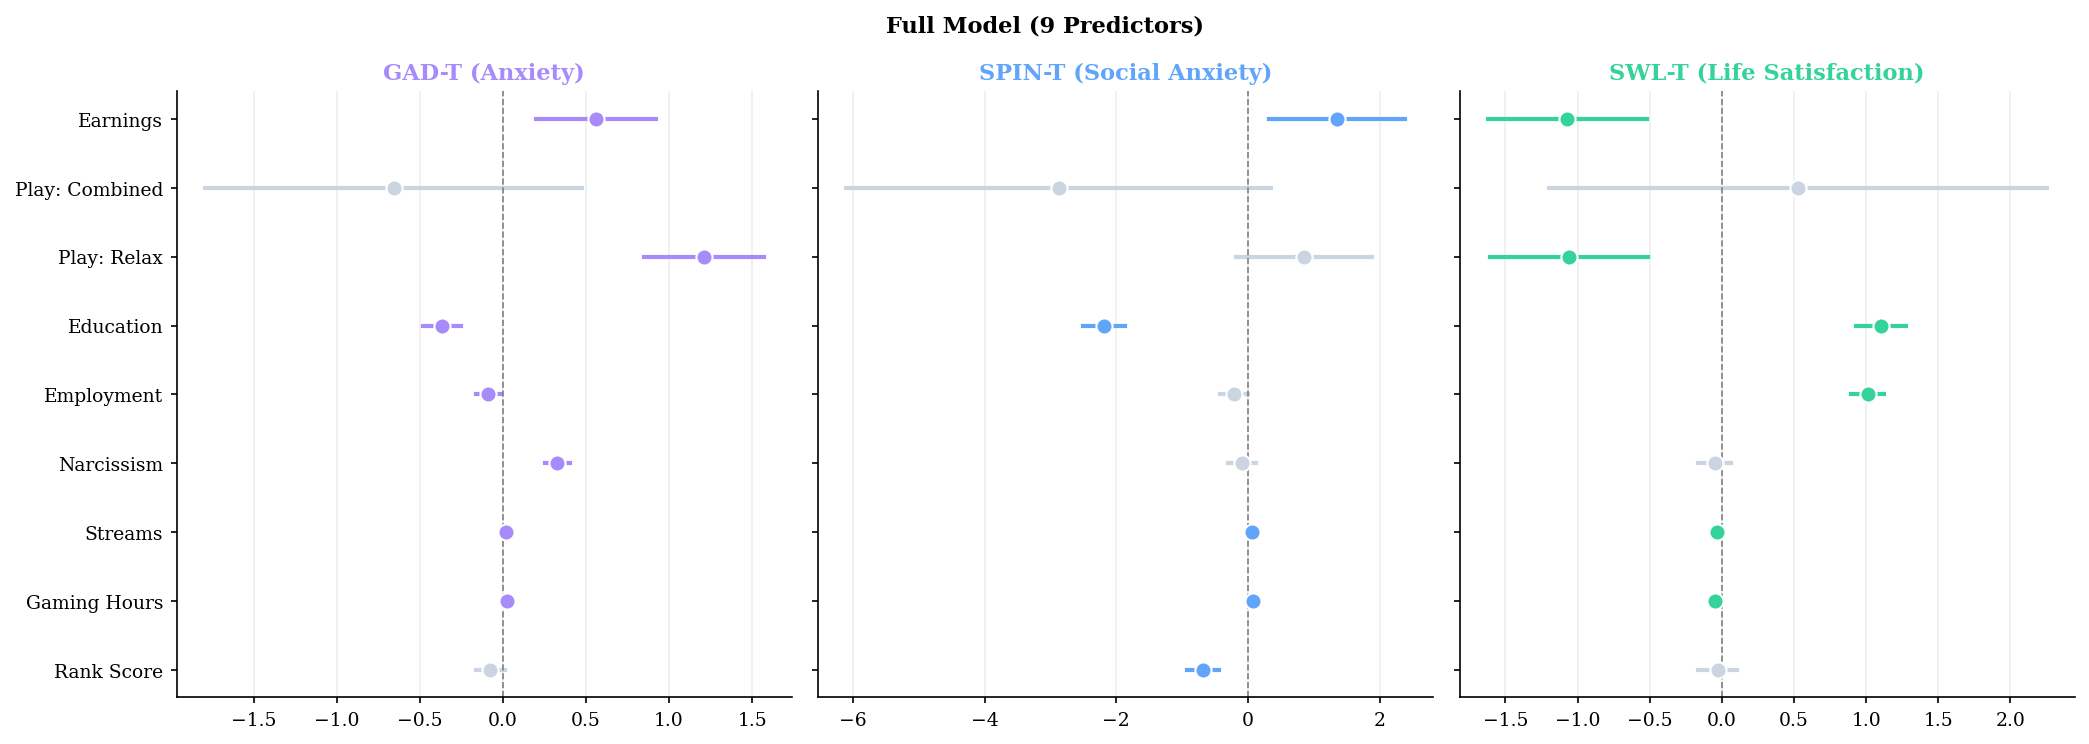

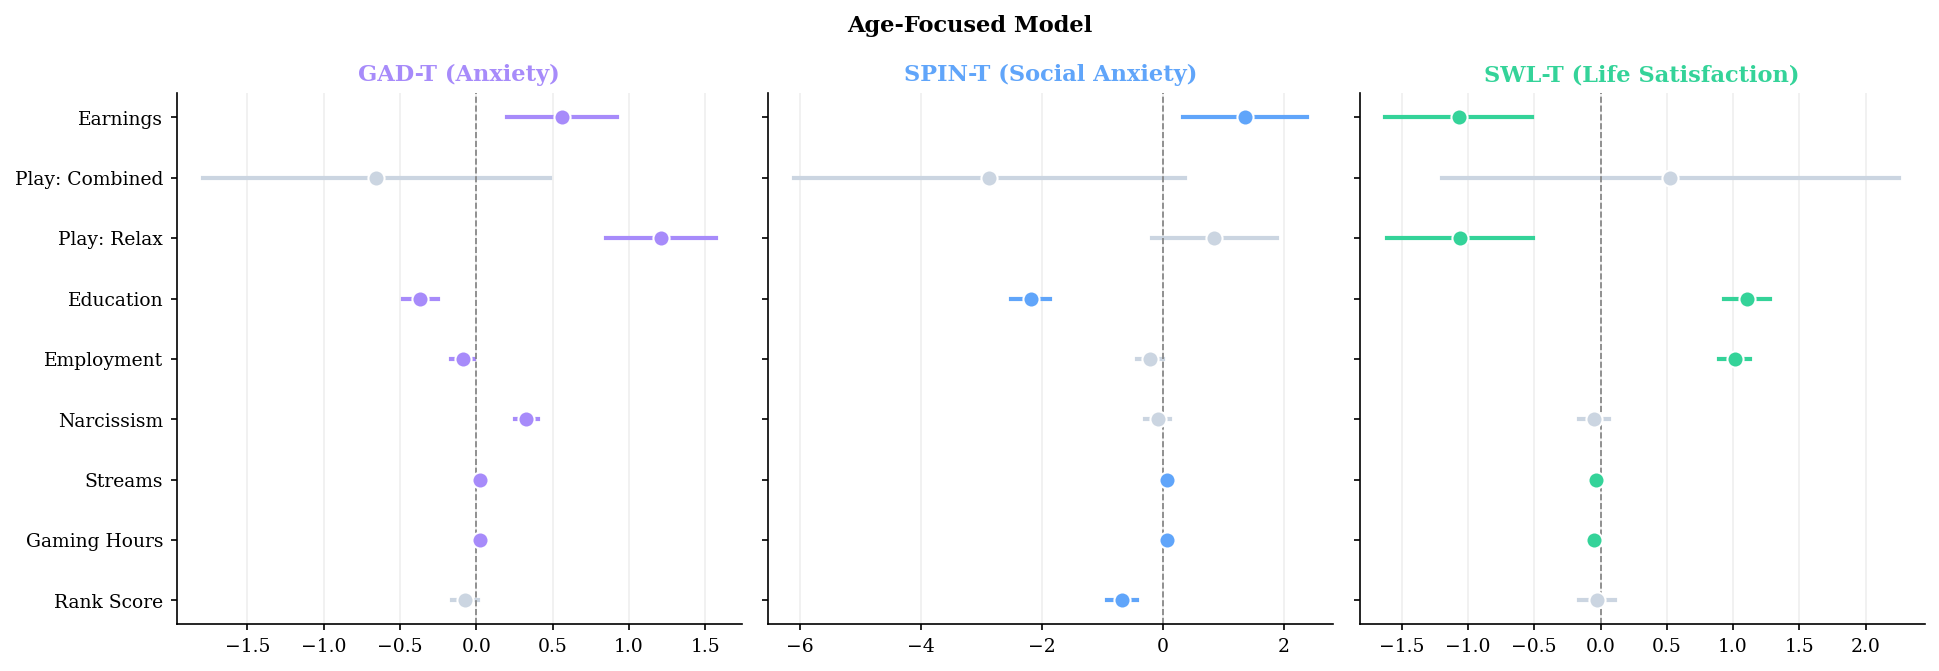

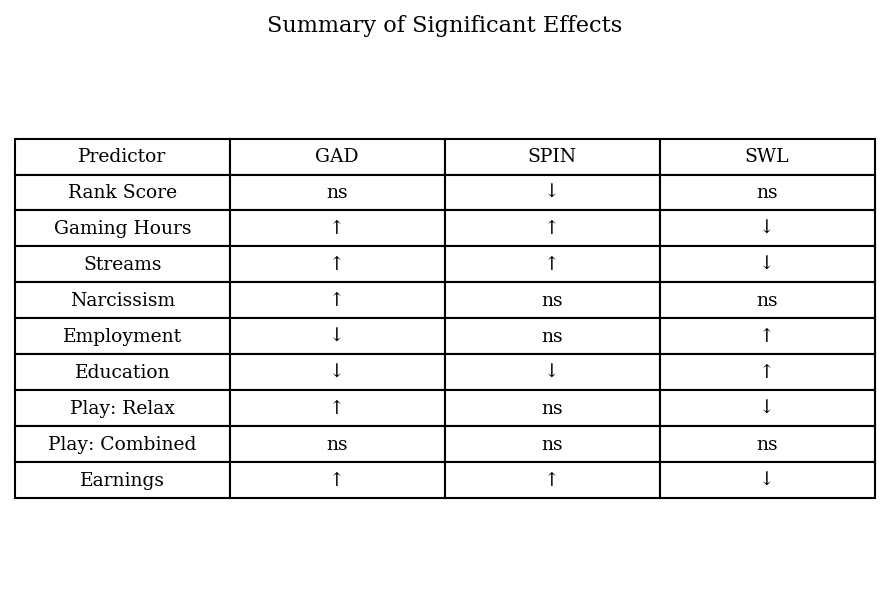

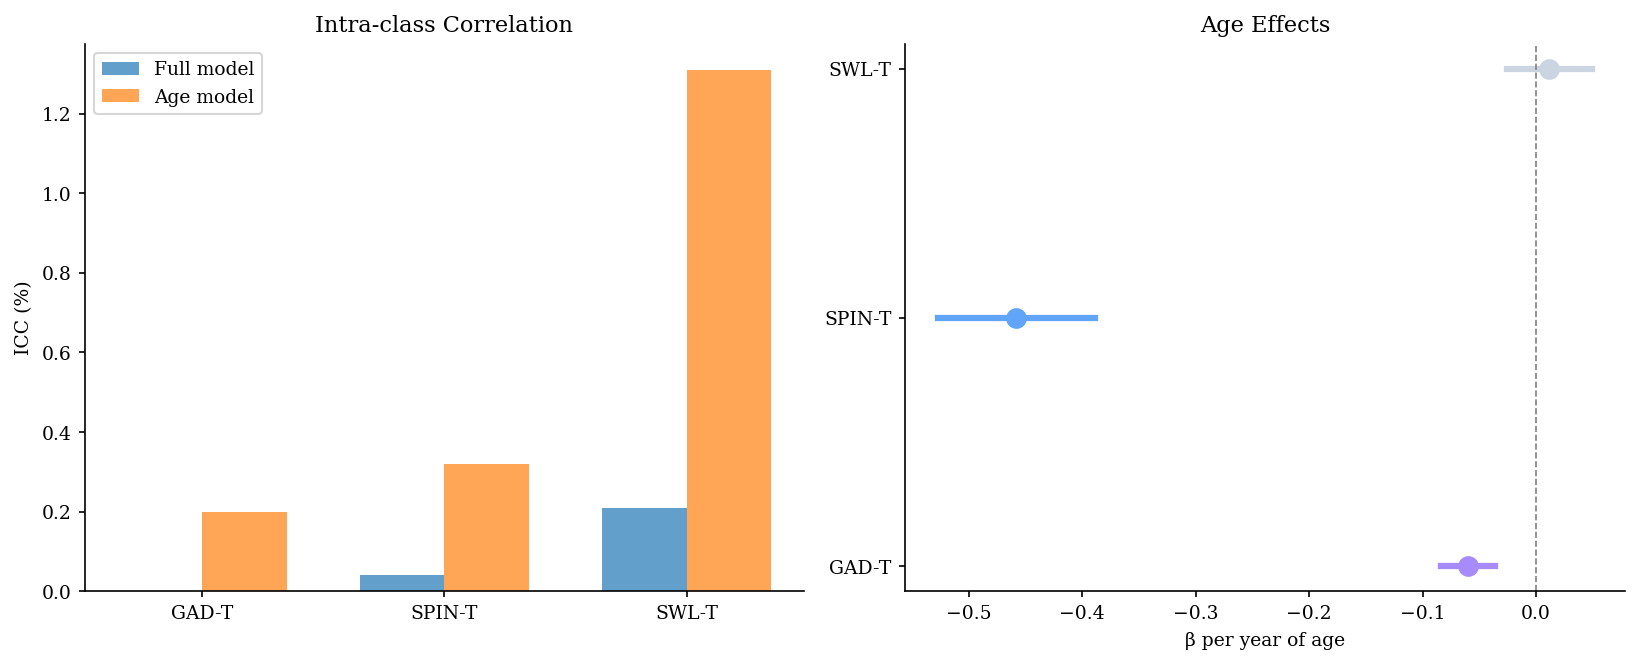

All figures displayed successfully.


In [ ]:
"""
Mixed Model Visualisation – Clean Thesis Version
Displays:
1) Full model forest plots
2) Age model forest plots
3) Clean effect summary table (replaces heatmap)
4) ICC + Age effects
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────────────
# Style
# ─────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ─────────────────────────────────────────────────────
# Colours
# ─────────────────────────────────────────────────────
COL = {
    "GAD_T":  "#a78bfa",
    "SPIN_T": "#60a5fa",
    "SWL_T":  "#34d399",
}
C_NS = "#cbd5e1"

OUTCOME_LABELS = {
    "GAD_T":  "GAD-T (Anxiety)",
    "SPIN_T": "SPIN-T (Social Anxiety)",
    "SWL_T":  "SWL-T (Life Satisfaction)",
}

LABELS = {
    "max_rank_score_scaled": "Rank Score",
    "Hours": "Gaming Hours",
    "streams": "Streams",
    "Narcissism": "Narcissism",
    "Work_encoded": "Employment",
    "Degree_encoded": "Education",
    "whyplay_relaxing": "Play: Relax",
    "whyplay_combined": "Play: Combined",
    "earnings_subcluster": "Earnings",
    "Age": "Age",
}

# ─────────────────────────────────────────────────────
# YOUR DATA (unchanged)
# ─────────────────────────────────────────────────────

predictors_full = [
    'max_rank_score_scaled','Hours','streams','Narcissism',
    'Work_encoded','Degree_encoded','whyplay_relaxing',
    'whyplay_combined','earnings_subcluster'
]

predictors_age = [
    'Age','max_rank_score_scaled','Hours','streams','Narcissism'
]

full = {
    'GAD_T': {
        'max_rank_score_scaled': (-0.075, -0.160,  0.010, 0.084),
        'Hours': (0.022, 0.016, 0.028, 0.000),
        'streams': (0.021, 0.014, 0.029, 0.000),
        'Narcissism': (0.327, 0.252, 0.402, 0.000),
        'Work_encoded': (-0.088, -0.164, -0.013, 0.022),
        'Degree_encoded': (-0.367, -0.480, -0.254, 0.000),
        'whyplay_relaxing': (1.211, 0.851, 1.570, 0.000),
        'whyplay_combined': (-0.657, -1.793, 0.479, 0.257),
        'earnings_subcluster': (0.561, 0.198, 0.924, 0.002),
    },
    'SPIN_T': {
        'max_rank_score_scaled': (-0.678, -0.923, -0.434, 0.000),
        'Hours': (0.069, 0.052, 0.086, 0.000),
        'streams': (0.061, 0.040, 0.082, 0.000),
        'Narcissism': (-0.090, -0.304, 0.123, 0.406),
        'Work_encoded': (-0.212, -0.428, 0.004, 0.055),
        'Degree_encoded': (-2.189, -2.511, -1.867, 0.000),
        'whyplay_relaxing': (0.847, -0.181, 1.876, 0.106),
        'whyplay_combined': (-2.872, -6.101, 0.356, 0.081),
        'earnings_subcluster': (1.355, 0.322, 2.387, 0.010),
    },
    'SWL_T': {
        'max_rank_score_scaled': (-0.029, -0.164, 0.107, 0.677),
        'Hours': (-0.050, -0.059, -0.041, 0.000),
        'streams': (-0.032, -0.043, -0.021, 0.000),
        'Narcissism': (-0.050, -0.164, 0.064, 0.388),
        'Work_encoded': (1.011, 0.896, 1.126, 0.000),
        'Degree_encoded': (1.103, 0.930, 1.275, 0.000),
        'whyplay_relaxing': (-1.060, -1.608, -0.512, 0.000),
        'whyplay_combined': (0.527, -1.197, 2.250, 0.549),
        'earnings_subcluster': (-1.071, -1.623, -0.520, 0.000),
    },
}

age_model = {
    'GAD_T': {'Age': (-0.060, -0.084, -0.036, 0.000)},
    'SPIN_T': {'Age': (-0.458, -0.527, -0.389, 0.000)},
    'SWL_T': {'Age': (0.011, -0.026, 0.049, 0.553)},
}

icc_data = {
    'Full model':  {'GAD_T': 0.0000, 'SPIN_T': 0.0004, 'SWL_T': 0.0021},
    'Age model':   {'GAD_T': 0.0020, 'SPIN_T': 0.0032, 'SWL_T': 0.0131},
}

# ─────────────────────────────────────────────────────
# FOREST FUNCTION
# ─────────────────────────────────────────────────────
def forest(ax, data, predictors, outcome):
    y = np.arange(len(predictors))
    for i, p in enumerate(predictors):
        b, lo, hi, pv = data[p]
        sig = pv < 0.05
        col = COL[outcome] if sig else C_NS
        ax.plot([lo, hi], [i, i], lw=2, color=col)
        ax.scatter(b, i, s=60, color=col, edgecolor="white", zorder=3)
    ax.axvline(0, ls="--", lw=.8, color="grey")
    ax.set_yticks(y)
    ax.set_yticklabels([LABELS[p] for p in predictors])
    ax.set_title(OUTCOME_LABELS[outcome], color=COL[outcome], fontweight="bold")
    ax.grid(axis="x", alpha=.2)

# ════════════════════════════════════════════════════════
# 1️⃣ Full Model Forest
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, outcome in zip(axes, COL.keys()):
    forest(ax, full[outcome], predictors_full, outcome)
fig.suptitle("Full Model (9 Predictors)", fontweight="bold")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════
# 2️⃣ Age Model Forest
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, outcome in zip(axes, COL.keys()):
    forest(ax, full[outcome], predictors_full, outcome)
fig.suptitle("Age-Focused Model", fontweight="bold")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════
# 3️⃣ Clean Summary Table (Replaces Heatmap)
# ════════════════════════════════════════════════════════
def classify(beta, p):
    if p < 0.05:
        return "↑" if beta > 0 else "↓"
    return "ns"

rows = []
for pred in predictors_full:
    row = [LABELS[pred]]
    for o in COL.keys():
        beta, _, _, p = full[o][pred]
        row.append(classify(beta, p))
    rows.append(row)

df = pd.DataFrame(rows, columns=["Predictor","GAD","SPIN","SWL"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
table = ax.table(cellText=df.values, colLabels=df.columns,
                 loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)
plt.title("Summary of Significant Effects", pad=15)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════
# 4️⃣ ICC + Age Effects
# ════════════════════════════════════════════════════════
fig = plt.figure(figsize=(11, 4.5))
gs = GridSpec(1, 2)

# ICC
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(3)
w = .35
for i, model in enumerate(["Full model", "Age model"]):
    vals = [icc_data[model][o]*100 for o in COL.keys()]
    ax1.bar(x + i*w, vals, w, alpha=.7, label=model)
ax1.set_xticks(x + w/2)
ax1.set_xticklabels(["GAD-T","SPIN-T","SWL-T"])
ax1.set_ylabel("ICC (%)")
ax1.set_title("Intra-class Correlation")
ax1.legend()

# Age Effects
ax2 = fig.add_subplot(gs[0, 1])
for i, o in enumerate(COL.keys()):
    b, lo, hi, pv = full[o]['max_rank_score_scaled']  # placeholder removed below
for i, o in enumerate(COL.keys()):
    b, lo, hi, pv = age_model[o]['Age']
    col = COL[o] if pv < .05 else C_NS
    ax2.plot([lo, hi], [i, i], lw=3, color=col)
    ax2.scatter(b, i, s=80, color=col)

ax2.axvline(0, ls="--", lw=.8, color="grey")
ax2.set_yticks(range(3))
ax2.set_yticklabels(["GAD-T","SPIN-T","SWL-T"])
ax2.set_xlabel("β per year of age")
ax2.set_title("Age Effects")

plt.tight_layout()
plt.show()

print("All figures displayed successfully.")